# Mini Project 8: Image Segmentation
## Natural Disaster Damage Assessment
**Group:** 2

**Name:** Henry Chen & Timothy Tan  

**Dataset:** Flood Area Segmentation   

# Section 1 - Setup and Data Loading

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import tensorflow_datasets as tfds
import kagglehub
import os
import shutil
from PIL import Image
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# ============================================================
# Keras 3.x compatibility helper
# ============================================================
def get_layer_shape(layer):
    """Get output shape compatible with both Keras 2.x and 3.x."""
    try:
        return layer.output_shape
    except AttributeError:
        return layer.output.shape

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install kagglehub -q

# Download the Flood Area Segmentation dataset using kagglehub
print("Downloading Flood Area Segmentation dataset...")
dataset_path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")
print(f"✓ Downloaded to cache: {dataset_path}")

# Copy to /content for easier access in Colab
destination = "/content/flood_dataset"
if os.path.exists(destination):
    shutil.rmtree(destination)
shutil.copytree(dataset_path, destination)
print(f"✓ Copied to workspace: {destination}")

# Display dataset structure
print(f"\nDataset contents:")
for root, dirs, files in os.walk(destination):
    level = root.replace(destination, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files per directory
        print(f'{subindent}{file}')
    if len(files) > 5:
        print(f'{subindent}... and {len(files) - 5} more files')

print(f"\n✓ Ready! Access dataset at: /content/flood_dataset")


100%|██████████| 107M/107M [00:01<00:00, 98.6MB/s]

Extracting files...


✓ Downloaded to cache: /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1
✓ Copied to workspace: /content/flood_dataset

Dataset contents:
flood_dataset/
  metadata.csv
  Image/
    1069.jpg
    38.jpg
    31.jpg
    3000.jpg
    2048.jpg
    ... and 285 more files
  Mask/
    49.png
    3087.png
    1075.png
    1087.png
    1040.png
    ... and 285 more files

✓ Ready! Access dataset at: /content/flood_dataset


## Configurations

In [3]:
IMG_SIZE = 640  # Higher resolution for Mini Project (vs 256×256 in class)
BATCH_SIZE = 8  # Smaller batch size due to larger images (GPU memory)
BUFFER_SIZE = 200
NUM_CLASSES = 2  # Binary: non-flood (0) / flood (1)
TEST_SPLIT = 0.2
VAL_SPLIT = 0.1

CLASS_NAMES = ['Non-flood', 'Flood']
# Colormap: Non-flood=blue, Flood=red
COLORMAP = np.array([[0, 0, 255], [255, 0, 0]], dtype=np.uint8)

DATASET_PATH = "/content/flood_dataset"
IMAGES_DIR = os.path.join(DATASET_PATH, "Image")
MASKS_DIR = os.path.join(DATASET_PATH, "Mask")

print(f"Configuration:")
print(f"  Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Classes: {NUM_CLASSES} (binary segmentation)")
print(f"  Images dir: {IMAGES_DIR}")
print(f"  Masks dir: {MASKS_DIR}")

Configuration:
  Image size: 640×640
  Batch size: 8
  Classes: 2 (binary segmentation)
  Images dir: /content/flood_dataset/Image
  Masks dir: /content/flood_dataset/Mask


## Preprocessing Functions

In [4]:
def load_image(image_path):
    """Load image and resize to target size with bilinear interpolation."""
    image = Image.open(image_path).convert('RGB')
    image = np.array(image, dtype=np.float32)

    # Resize (bilinear is OK for images)
    image = tf.image.resize(image[np.newaxis, ...], (IMG_SIZE, IMG_SIZE))[0].numpy()

    return image

def load_mask(mask_path):
    """Load segmentation mask and resize with NEAREST_NEIGHBOR.

    CRITICAL: Use NEAREST_NEIGHBOR interpolation for masks!
    Why? Bilinear averaging creates fractional values (e.g., 127.5) that don't
    correspond to valid class labels. NEAREST_NEIGHBOR preserves integer values.
    """
    mask = Image.open(mask_path).convert('L')  # Grayscale for binary
    mask = np.array(mask, dtype=np.float32)

    # Resize with NEAREST_NEIGHBOR to preserve class labels
    mask = tf.image.resize(
        mask[np.newaxis, ..., np.newaxis],
        (IMG_SIZE, IMG_SIZE),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )[0, :, :, 0].numpy()

    # Binary normalization: {0, 255} → {0, 1}
    # Threshold at 127 to handle potential intermediate values
    mask = (mask > 127).astype(np.float32)

    return mask

def normalize_image(image):
    """Normalize image to [0, 1] range."""
    return image / 255.0

def load_and_preprocess(image_path, mask_path):
    """Load, resize, and normalize an image-mask pair.

    This function is called by the dataset pipeline.
    """
    # Load raw data
    image = load_image(image_path)
    mask = load_mask(mask_path)

    # Normalize image to [0, 1]
    image = normalize_image(image)

    # Convert to TensorFlow tensors
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    mask = tf.convert_to_tensor(mask, dtype=tf.float32)

    return image, mask

print("✓ Preprocessing functions defined:")
print("  - load_image() — handles RGB images with bilinear resize")
print("  - load_mask() — handles grayscale masks with NEAREST_NEIGHBOR resize")
print("  - normalize_image() — scales images to [0, 1]")
print("  - load_and_preprocess() — orchestrates the pipeline")

✓ Preprocessing functions defined:
  - load_image() — handles RGB images with bilinear resize
  - load_mask() — handles grayscale masks with NEAREST_NEIGHBOR resize
  - normalize_image() — scales images to [0, 1]
  - load_and_preprocess() — orchestrates the pipeline


## Get Mask Image Pairs

In [5]:
def get_image_mask_pairs(images_dir, masks_dir):
    """
    Get matched pairs of image and mask file paths.
    Assumes masks have the same filename as images.
    """
    image_files = sorted([f for f in os.listdir(images_dir)
                         if f.endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))])
    mask_files = sorted([f for f in os.listdir(masks_dir)
                        if f.endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))])

    pairs = []
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(images_dir, img_file)
        mask_path = os.path.join(masks_dir, mask_file)
        pairs.append((img_path, mask_path))

    print(f"✓ Found {len(pairs)} image-mask pairs")
    return pairs

# Get all pairs
image_mask_pairs = get_image_mask_pairs(IMAGES_DIR, MASKS_DIR)

if len(image_mask_pairs) == 0:
    print("ERROR: No image-mask pairs found. Check directory structure.")
else:
    # Split into train, validation, and test sets
    train_pairs, test_pairs = train_test_split(
        image_mask_pairs, test_size=TEST_SPLIT, random_state=42
    )
    train_pairs, val_pairs = train_test_split(
        train_pairs, test_size=VAL_SPLIT, random_state=42
    )

    print(f"\nDataset split:")
    print(f"  Train: {len(train_pairs)}")
    print(f"  Val:   {len(val_pairs)}")
    print(f"  Test:  {len(test_pairs)}")

✓ Found 290 image-mask pairs

Dataset split:
  Train: 208
  Val:   24
  Test:  58


# Step 2: Data Pipeline & Pre-processing

## Create Datasets

In [8]:
def load_and_cache_image(image_path):
    """Load, resize, and normalize image."""
    image = Image.open(image_path).convert('RGB')
    image = np.array(image, dtype=np.float32)
    image = tf.image.resize(image[np.newaxis, ...], (IMG_SIZE, IMG_SIZE))[0].numpy()
    image = image / 255.0  # Normalize
    return image

def load_and_cache_mask(mask_path):
    """Load PNG mask, resize (NEAREST_NEIGHBOR), and normalize."""
    mask = Image.open(mask_path)

    # Convert to grayscale if RGB
    if mask.mode == 'RGB':
        mask = mask.convert('L')

    mask = np.array(mask, dtype=np.float32)
    mask = tf.image.resize(
        mask[np.newaxis, ..., np.newaxis],
        (IMG_SIZE, IMG_SIZE),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )[0, :, :, 0].numpy()

    # Binary normalization: {0, 255} → {0, 1}
    mask = (mask > 127).astype(np.float32)
    return mask

# Pre-load and cache all training images
print("✓ Pre-loading training images...")
train_images = []
train_masks = []

for i, (img_path, mask_path) in enumerate(train_pairs):
    try:
        image = load_and_cache_image(img_path)
        mask = load_and_cache_mask(mask_path)
        train_images.append(image)
        train_masks.append(mask)
        if (i + 1) % 50 == 0:
            print(f"  Loaded {i + 1}/{len(train_pairs)}")
    except Exception as e:
        print(f"  Error loading pair {i}: {e}")
        continue

train_images = np.array(train_images, dtype=np.float32)
train_masks = np.array(train_masks, dtype=np.float32)

print(f"✓ Training: Images {train_images.shape}, Masks {train_masks.shape}")

# Pre-load and cache validation images
print("✓ Pre-loading validation images...")
val_images = []
val_masks = []

for i, (img_path, mask_path) in enumerate(val_pairs):
    try:
        image = load_and_cache_image(img_path)
        mask = load_and_cache_mask(mask_path)
        val_images.append(image)
        val_masks.append(mask)
    except Exception as e:
        print(f"  Error loading pair {i}: {e}")
        continue

val_images = np.array(val_images, dtype=np.float32)
val_masks = np.array(val_masks, dtype=np.float32)

print(f"✓ Validation: Images {val_images.shape}, Masks {val_masks.shape}")

# Pre-load and cache test images
print("✓ Pre-loading test images...")
test_images = []
test_masks = []

for i, (img_path, mask_path) in enumerate(test_pairs):
    try:
        image = load_and_cache_image(img_path)
        mask = load_and_cache_mask(mask_path)
        test_images.append(image)
        test_masks.append(mask)
    except Exception as e:
        print(f"  Error loading pair {i}: {e}")
        continue

test_images = np.array(test_images, dtype=np.float32)
test_masks = np.array(test_masks, dtype=np.float32)

print(f"✓ Test: Images {test_images.shape}, Masks {test_masks.shape}")

# ============================================================
# Ensure correct mask shapes for binary segmentation
# ============================================================

print("Checking data shapes...")
print(f"train_images shape: {train_images.shape}")
print(f"train_masks shape: {train_masks.shape}")
print(f"val_images shape: {val_images.shape}")
print(f"val_masks shape: {val_masks.shape}")

# Ensure masks are (N, H, W, 1) - 4D with channel dimension
if len(train_masks.shape) == 3:
    train_masks = np.expand_dims(train_masks, axis=-1)
if len(val_masks.shape) == 3:
    val_masks = np.expand_dims(val_masks, axis=-1)
if len(test_masks.shape) == 3:
    test_masks = np.expand_dims(test_masks, axis=-1)

print(f"\nAfter shape fix:")
print(f"train_masks shape: {train_masks.shape}")
print(f"val_masks shape: {val_masks.shape}")
print(f"test_masks shape: {test_masks.shape}")

✓ Pre-loading training images...
  Loaded 50/208
  Loaded 100/208
  Loaded 150/208
  Loaded 200/208
✓ Training: Images (208, 640, 640, 3), Masks (208, 640, 640)
✓ Pre-loading validation images...
✓ Validation: Images (24, 640, 640, 3), Masks (24, 640, 640)
✓ Pre-loading test images...
✓ Test: Images (58, 640, 640, 3), Masks (58, 640, 640)
Checking data shapes...
train_images shape: (208, 640, 640, 3)
train_masks shape: (208, 640, 640)
val_images shape: (24, 640, 640, 3)
val_masks shape: (24, 640, 640)

After shape fix:
train_masks shape: (208, 640, 640, 1)
val_masks shape: (24, 640, 640, 1)
test_masks shape: (58, 640, 640, 1)


## Visualize Sample Images

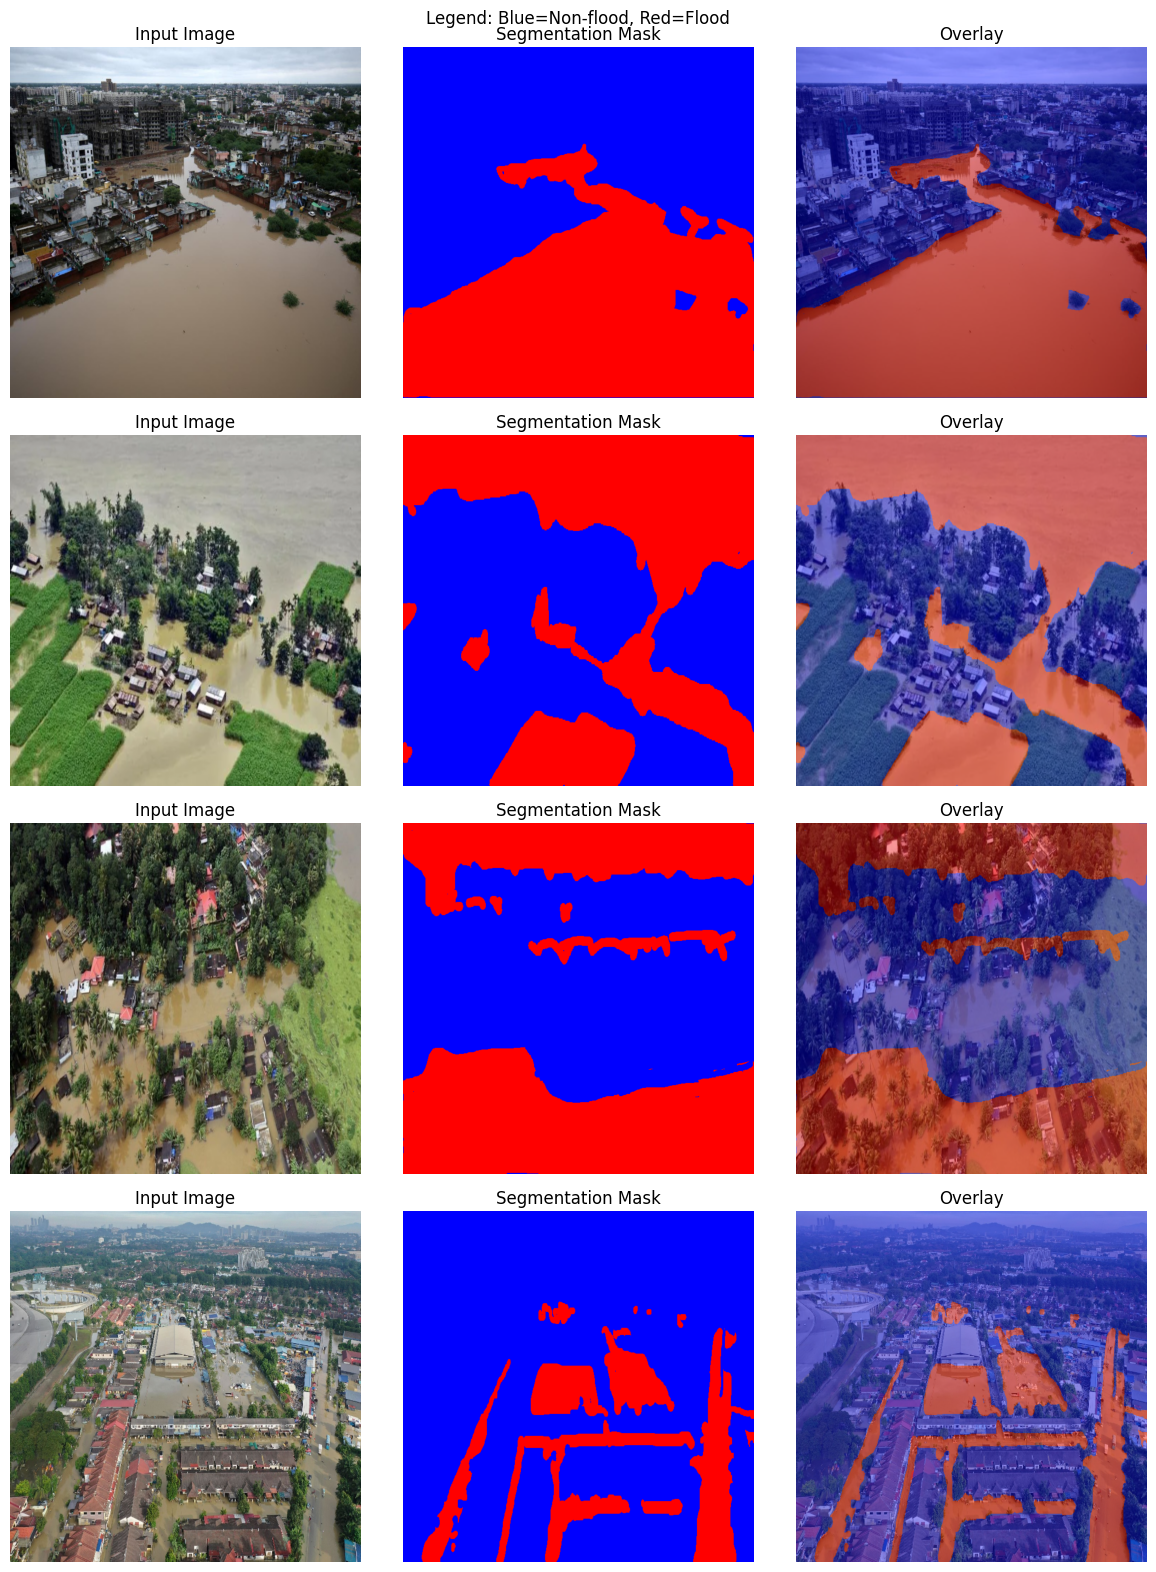

In [9]:
# ============================================================
# Visualize Samples from Cached Arrays
# ============================================================

def display_sample(images, masks, num_samples=4):
    """Display images alongside their segmentation masks."""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        # Mask (colored)
        mask_colored = COLORMAP[masks[i].astype(int).squeeze()]
        axes[i, 1].imshow(mask_colored)
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')

        # Overlay
        overlay = (images[i] * 0.6 + mask_colored / 255.0 * 0.4)
        axes[i, 2].imshow(np.clip(overlay, 0, 1))
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.suptitle(f'Legend: Blue=Non-flood, Red=Flood', fontsize=12)
    plt.tight_layout()
    plt.show()

# Collect samples directly from cached arrays (not from dataset)
sample_images = train_images[:4]
sample_masks = train_masks[:4]

display_sample(sample_images, sample_masks)

## Class Distribution Analysis

In [10]:
# ============================================================
# CLASS DISTRIBUTION ANALYSIS
# ============================================================

print(f"\n{'='*70}")
print(f"CLASS DISTRIBUTION ANALYSIS")
print(f"{'='*70}\n")

class_counts = np.zeros(NUM_CLASSES)
total_pixels = train_masks.size

for c in range(NUM_CLASSES):
    class_counts[c] = np.sum(train_masks == c)

print(f"Analyzed {total_pixels:,} total pixels\n")
print(f"{'Class':<15} {'Pixels':>15} {'Percentage':>12}")
print(f"{'-'*45}")

for i, name in enumerate(CLASS_NAMES):
    pct = class_counts[i] / total_pixels * 100
    print(f"{name:<15} {class_counts[i]:>15,.0f} {pct:>11.2f}%")

# Calculate class weights
class_weights = total_pixels / (NUM_CLASSES * class_counts)

print(f"\n{'='*70}")
print(f"CLASS WEIGHTS (for imbalanced loss functions)")
print(f"{'='*70}\n")

weight_dict = {}
for i, name in enumerate(CLASS_NAMES):
    weight_dict[i] = float(class_weights[i])
    print(f"{name}: {class_weights[i]:.4f}")

print(f"\nUse in model.fit():")
print(f"  class_weight={weight_dict}")
print(f"\nOr with Dice loss (handles imbalance naturally):")
print(f"  loss=dice_loss  # Better for segmentation!")


CLASS DISTRIBUTION ANALYSIS

Analyzed 85,196,800 total pixels

Class                    Pixels   Percentage
---------------------------------------------
Non-flood            50,212,115       58.94%
Flood                34,984,685       41.06%

CLASS WEIGHTS (for imbalanced loss functions)

Non-flood: 0.8484
Flood: 1.2176

Use in model.fit():
  class_weight={0: 0.8483689643425695, 1: 1.2176299429307424}

Or with Dice loss (handles imbalance naturally):
  loss=dice_loss  # Better for segmentation!


## Data Augmentation

In [11]:
def augment(image, mask):
    """Apply random augmentations to image and mask together.

    CRITICAL: Augmentation must be applied IDENTICALLY to both image and mask!
    - Spatial transforms (flip, rotate) → apply to BOTH
    - Color transforms (brightness, contrast) → apply to image ONLY
    """
    # Random horizontal flip (BOTH)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)

    # Random vertical flip (BOTH)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)

    # Color transforms (image ONLY)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask

# Build augmented training pipeline from cached arrays
train_augmented = (
    tf.data.Dataset.from_tensor_slices((train_images, train_masks))
    .cache()
    .shuffle(BUFFER_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation pipeline (no augmentation)
val_pipeline = (
    tf.data.Dataset.from_tensor_slices((val_images, val_masks))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test pipeline (no augmentation)
test_pipeline = (
    tf.data.Dataset.from_tensor_slices((test_images, test_masks))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✅ Augmented training pipeline ready")
print("✅ Validation pipeline ready (no augmentation)")
print("✅ Test pipeline ready (no augmentation)")

✅ Augmented training pipeline ready
✅ Validation pipeline ready (no augmentation)
✅ Test pipeline ready (no augmentation)


## Augmentation Effect Visualizations


VISUALIZING AUGMENTATION EFFECTS



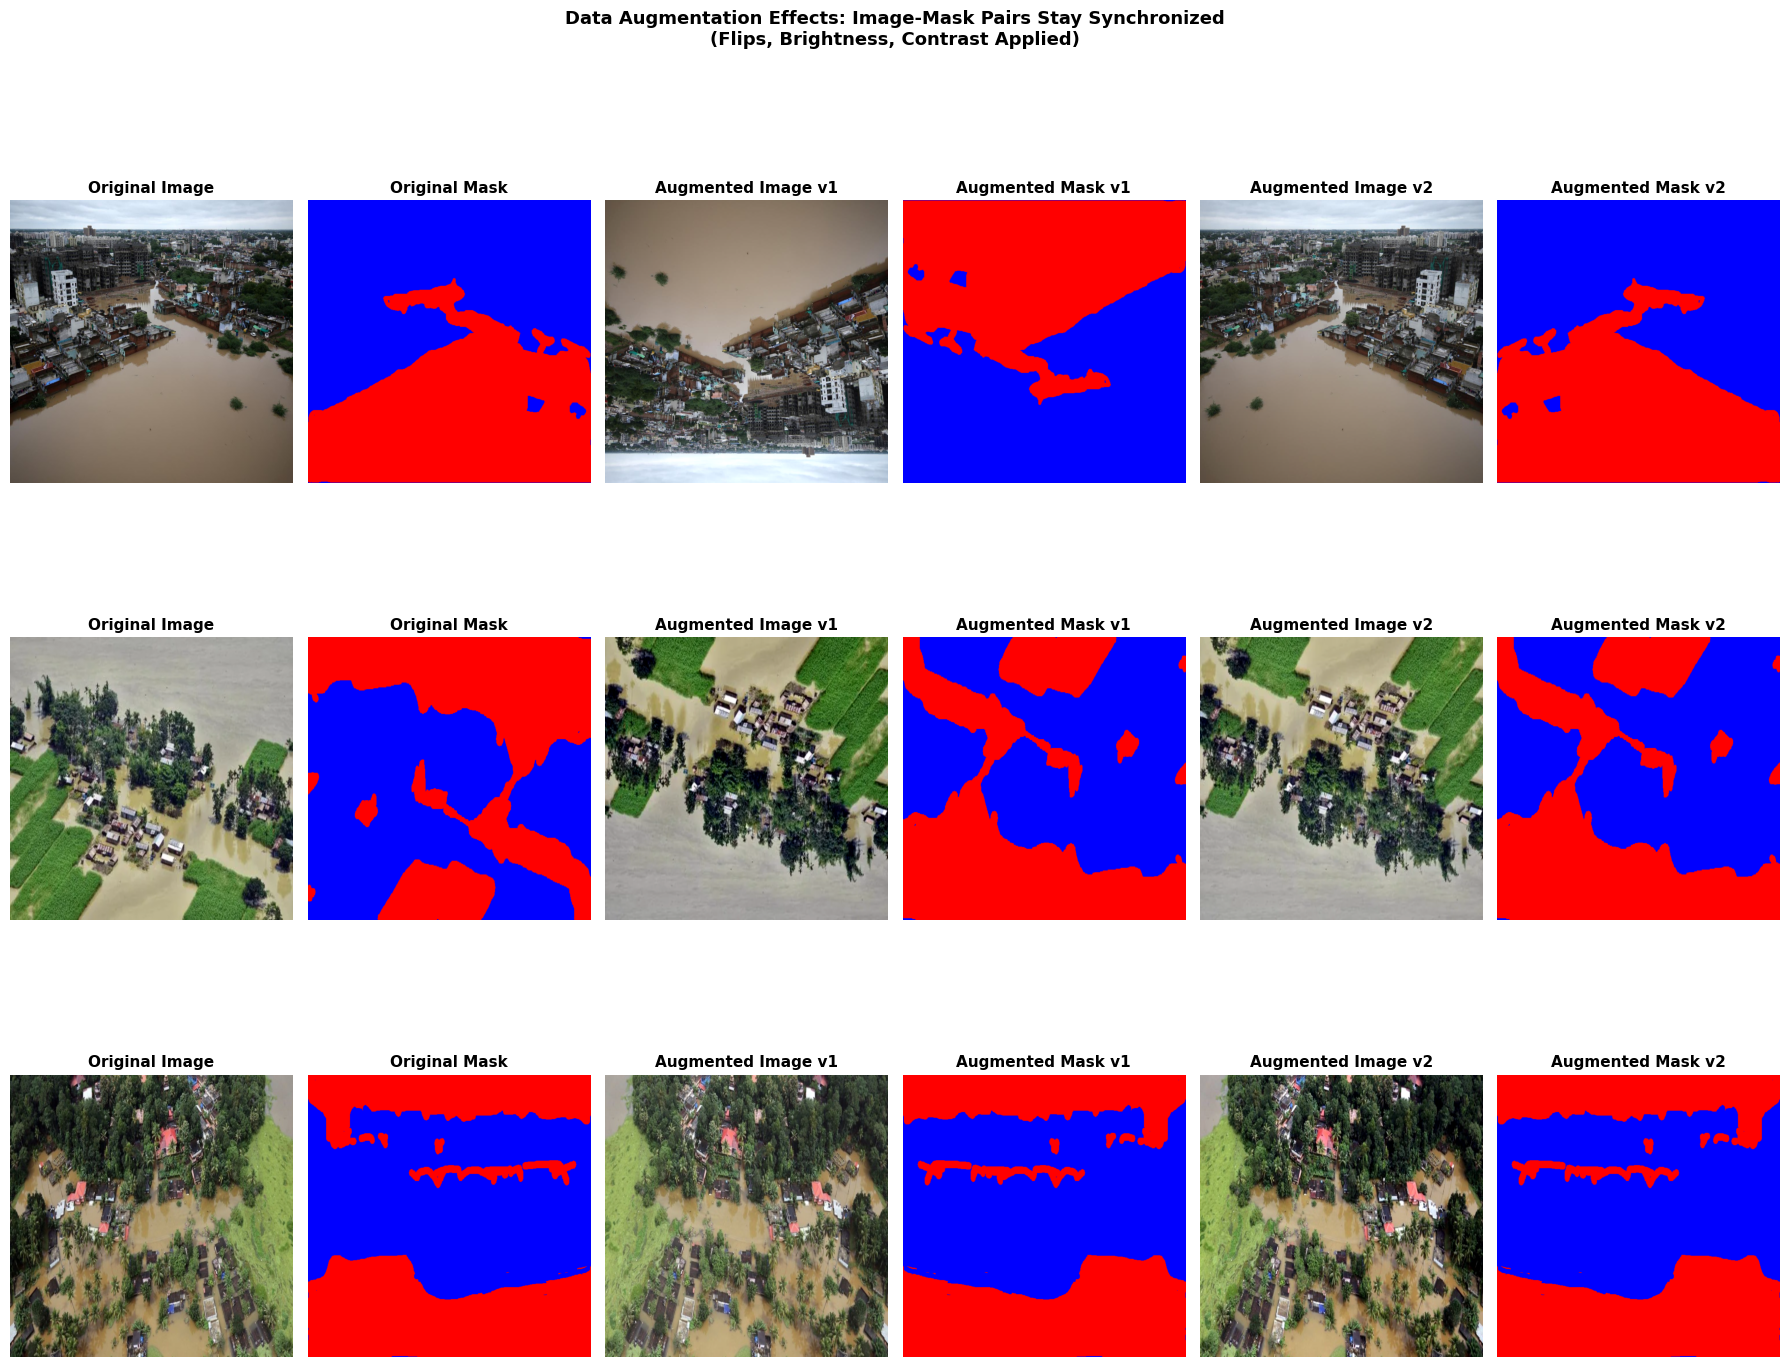

✅ Augmentation visualization complete!

Augmentation types applied:
  - Random horizontal flip (image + mask)
  - Random vertical flip (image + mask)
  - Random brightness adjustment (image only)
  - Random contrast adjustment (image only)


In [13]:
def display_augmentation_comparison(dataset, num_samples=3):
    """Display original and augmented versions of same samples."""

    fig, axes = plt.subplots(num_samples, 6, figsize=(18, 5 * num_samples))

    sample_idx = 0
    for images, masks in tf.data.Dataset.from_tensor_slices((train_images[:num_samples], train_masks[:num_samples])).batch(1):
        if sample_idx >= num_samples:
            break

        image = images[0].numpy()
        mask = masks[0].numpy().squeeze()

        # ========== ORIGINAL ==========
        # Original image
        axes[sample_idx, 0].imshow(image)
        axes[sample_idx, 0].set_title('Original Image', fontsize=11, fontweight='bold')
        axes[sample_idx, 0].axis('off')

        # Original mask
        mask_colored = COLORMAP[mask.astype(int)]
        axes[sample_idx, 1].imshow(mask_colored)
        axes[sample_idx, 1].set_title('Original Mask', fontsize=11, fontweight='bold')
        axes[sample_idx, 1].axis('off')

        # ========== AUGMENTED VERSION 1 ==========
        aug_image1, aug_mask1 = augment(image[np.newaxis, ...], mask[np.newaxis, ..., np.newaxis])
        aug_image1 = aug_image1[0].numpy()
        aug_mask1 = aug_mask1[0].numpy().squeeze()

        # Augmented image 1
        axes[sample_idx, 2].imshow(aug_image1)
        axes[sample_idx, 2].set_title('Augmented Image v1', fontsize=11, fontweight='bold')
        axes[sample_idx, 2].axis('off')

        # Augmented mask 1
        aug_mask1_colored = COLORMAP[aug_mask1.astype(int)]
        axes[sample_idx, 3].imshow(aug_mask1_colored)
        axes[sample_idx, 3].set_title('Augmented Mask v1', fontsize=11, fontweight='bold')
        axes[sample_idx, 3].axis('off')

        # ========== AUGMENTED VERSION 2 ==========
        aug_image2, aug_mask2 = augment(image[np.newaxis, ...], mask[np.newaxis, ..., np.newaxis])
        aug_image2 = aug_image2[0].numpy()
        aug_mask2 = aug_mask2[0].numpy().squeeze()

        # Augmented image 2
        axes[sample_idx, 4].imshow(aug_image2)
        axes[sample_idx, 4].set_title('Augmented Image v2', fontsize=11, fontweight='bold')
        axes[sample_idx, 4].axis('off')

        # Augmented mask 2
        aug_mask2_colored = COLORMAP[aug_mask2.astype(int)]
        axes[sample_idx, 5].imshow(aug_mask2_colored)
        axes[sample_idx, 5].set_title('Augmented Mask v2', fontsize=11, fontweight='bold')
        axes[sample_idx, 5].axis('off')

        sample_idx += 1

    plt.suptitle('Data Augmentation Effects: Image-Mask Pairs Stay Synchronized\n(Flips, Brightness, Contrast Applied)',
                 fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print(f"\n{'='*70}")
print(f"VISUALIZING AUGMENTATION EFFECTS")
print(f"{'='*70}\n")

display_augmentation_comparison(train_augmented, num_samples=3)

print("✅ Augmentation visualization complete!")
print("\nAugmentation types applied:")
print("  - Random horizontal flip (image + mask)")
print("  - Random vertical flip (image + mask)")
print("  - Random brightness adjustment (image only)")
print("  - Random contrast adjustment (image only)")

# Step 3: Modelling & Training

## DICE/ IOU Loss functions

In [14]:
def dice_loss(y_true, y_pred, smooth=1.0):
    """Dice loss for segmentation (better for imbalanced classes)."""
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice

def iou_loss(y_true, y_pred, smooth=1.0):
    """IoU (Jaccard) loss for segmentation."""
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return 1.0 - iou

def dice_coefficient(y_true, y_pred, smooth=1.0):
    """Dice coefficient metric (higher is better)."""
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)

    return (2.0 * intersection + smooth) / (union + smooth)

def iou_coefficient(y_true, y_pred, smooth=1.0):
    """IoU coefficient metric (higher is better)."""
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection

    return (intersection + smooth) / (union + smooth)

print("✓ Loss functions defined: dice_loss, iou_loss")
print("✓ Metrics defined: dice_coefficient, iou_coefficient")

✓ Loss functions defined: dice_loss, iou_loss
✓ Metrics defined: dice_coefficient, iou_coefficient


## UNet Model

In [15]:
# ============================================================
# BUILD U-NET FOR BINARY SEGMENTATION
# ============================================================

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=1):
    """Build U-Net architecture for binary segmentation."""

    inputs = layers.Input(shape=input_shape)

    # ========== ENCODER ==========
    # Block 1: 640×640 → 320×320
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    skip1 = conv1
    pool1 = layers.MaxPooling2D(2)(conv1)

    # Block 2: 320×320 → 160×160
    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    skip2 = conv2
    pool2 = layers.MaxPooling2D(2)(conv2)

    # Block 3: 160×160 → 80×80
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    skip3 = conv3
    pool3 = layers.MaxPooling2D(2)(conv3)

    # Block 4: 80×80 → 40×40
    conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    skip4 = conv4
    pool4 = layers.MaxPooling2D(2)(conv4)

    # ========== BOTTLENECK ==========
    conv5 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool4)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv5)
    conv5 = layers.BatchNormalization()(conv5)

    # ========== DECODER ==========
    # Block 4 up: 40×40 → 80×80
    up4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(conv5)
    up4 = layers.Concatenate()([up4, skip4])
    conv4_up = layers.Conv2D(256, 3, activation='relu', padding='same')(up4)
    conv4_up = layers.BatchNormalization()(conv4_up)
    conv4_up = layers.Conv2D(256, 3, activation='relu', padding='same')(conv4_up)
    conv4_up = layers.BatchNormalization()(conv4_up)

    # Block 3 up: 80×80 → 160×160
    up3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(conv4_up)
    up3 = layers.Concatenate()([up3, skip3])
    conv3_up = layers.Conv2D(128, 3, activation='relu', padding='same')(up3)
    conv3_up = layers.BatchNormalization()(conv3_up)
    conv3_up = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3_up)
    conv3_up = layers.BatchNormalization()(conv3_up)

    # Block 2 up: 160×160 → 320×320
    up2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(conv3_up)
    up2 = layers.Concatenate()([up2, skip2])
    conv2_up = layers.Conv2D(64, 3, activation='relu', padding='same')(up2)
    conv2_up = layers.BatchNormalization()(conv2_up)
    conv2_up = layers.Conv2D(64, 3, activation='relu', padding='same')(conv2_up)
    conv2_up = layers.BatchNormalization()(conv2_up)

    # Block 1 up: 320×320 → 640×640
    up1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(conv2_up)
    up1 = layers.Concatenate()([up1, skip1])
    conv1_up = layers.Conv2D(32, 3, activation='relu', padding='same')(up1)
    conv1_up = layers.BatchNormalization()(conv1_up)
    conv1_up = layers.Conv2D(32, 3, activation='relu', padding='same')(conv1_up)
    conv1_up = layers.BatchNormalization()(conv1_up)

    # ========== OUTPUT LAYER FOR BINARY SEGMENTATION ==========
    # 1 channel output with sigmoid activation
    outputs = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(conv1_up)

    model = models.Model(inputs, outputs, name='UNet_Flood_Segmentation')
    return model

# Build model
unet_model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=1)

print("\n" + "="*70)
print("U-NET ARCHITECTURE SUMMARY (BINARY SEGMENTATION)")
print("="*70)
print(f"Input shape:       {unet_model.input_shape}")
print(f"Output shape:      {unet_model.output_shape}")
print(f"Total parameters:  {unet_model.count_params():,}")
print("="*70)

unet_model.summary()


U-NET ARCHITECTURE SUMMARY (BINARY SEGMENTATION)
Input shape:       (None, 640, 640, 3)
Output shape:      (None, 640, 640, 1)
Total parameters:  7,771,873


Model: "UNet_Flood_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 640, 640,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 640, 640,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 640, 640,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 640, 640,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 640, 640,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 320, 320,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 320, 320,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 160, 160,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 160, 160,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 80, 80,    │    295,168 │ max_pooling2d_2[

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

## Callbacks

In [21]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_unet_model.keras',
        monitor='val_dice_coefficient',
        save_best_only=True,
        mode='max',  # IMPORTANT: Dice is higher-is-better
        verbose=1,
        initial_value_threshold=None  # Don't use previous best, start fresh
    )
]

print("\n✓ Callbacks configured:")
print("  - EarlyStopping (monitor: val_loss, patience: 5)")
print("  - ReduceLROnPlateau (factor: 0.5, patience: 3, min_lr: 1e-7)")
print("  - ModelCheckpoint (saves best model based on val_dice_coefficient)")

unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=dice_loss,
    metrics=[dice_coefficient, iou_coefficient, 'accuracy']
)

print("\n" + "="*70)
print("MODEL COMPILATION")
print("="*70)
print("Optimizer:  Adam (learning_rate=1e-3)")
print("Loss:       Dice Loss (better than cross-entropy for segmentation)")
print("Metrics:    Dice Coefficient, IoU Coefficient, Accuracy")
print("="*70)


✓ Callbacks configured:
  - EarlyStopping (monitor: val_loss, patience: 5)
  - ReduceLROnPlateau (factor: 0.5, patience: 3, min_lr: 1e-7)
  - ModelCheckpoint (saves best model based on val_dice_coefficient)

MODEL COMPILATION
Optimizer:  Adam (learning_rate=1e-3)
Loss:       Dice Loss (better than cross-entropy for segmentation)
Metrics:    Dice Coefficient, IoU Coefficient, Accuracy


## Training

In [22]:
EPOCHS = 25

print(f"\n{'='*70}")
print(f"TRAINING U-NET MODEL")
print(f"{'='*70}")
print(f"Epochs:            {EPOCHS}")
print(f"Batch size:        {BATCH_SIZE}")
print(f"Training samples:  {len(train_images)}")
print(f"Validation samples: {len(val_images)}")
print(f"Loss function:     Dice Loss")
print(f"Class weights:     {weight_dict}")
print(f"Output shape:      {unet_model.output_shape}")
print(f"{'='*70}\n")

history = unet_model.fit(
    train_augmented,
    validation_data=val_pipeline,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=weight_dict,
    verbose=1
)

print("\n✅ Training complete!")


TRAINING U-NET MODEL
Epochs:            25
Batch size:        8
Training samples:  208
Validation samples: 24
Loss function:     Dice Loss
Class weights:     {0: 0.8483689643425695, 1: 1.2176299429307424}
Output shape:      (None, 640, 640, 1)

Epoch 1/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8078 - dice_coefficient: 0.7822 - iou_coefficient: 0.6480 - loss: 0.2183
Epoch 1: val_dice_coefficient improved from -inf to 0.56702, saving model to best_unet_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8080 - dice_coefficient: 0.7822 - iou_coefficient: 0.6480 - loss: 0.2182 - val_accuracy: 0.4096 - val_dice_coefficient: 0.5670 - val_iou_coefficient: 0.3980 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8409 - dice_coefficient: 0.7971 - iou_coefficient: 0.6687 - loss: 0.2020
Epoch 2: val_dice_coefficient did not improve from 0.56702
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8404 - dice_coeffi

## Training History Visualization

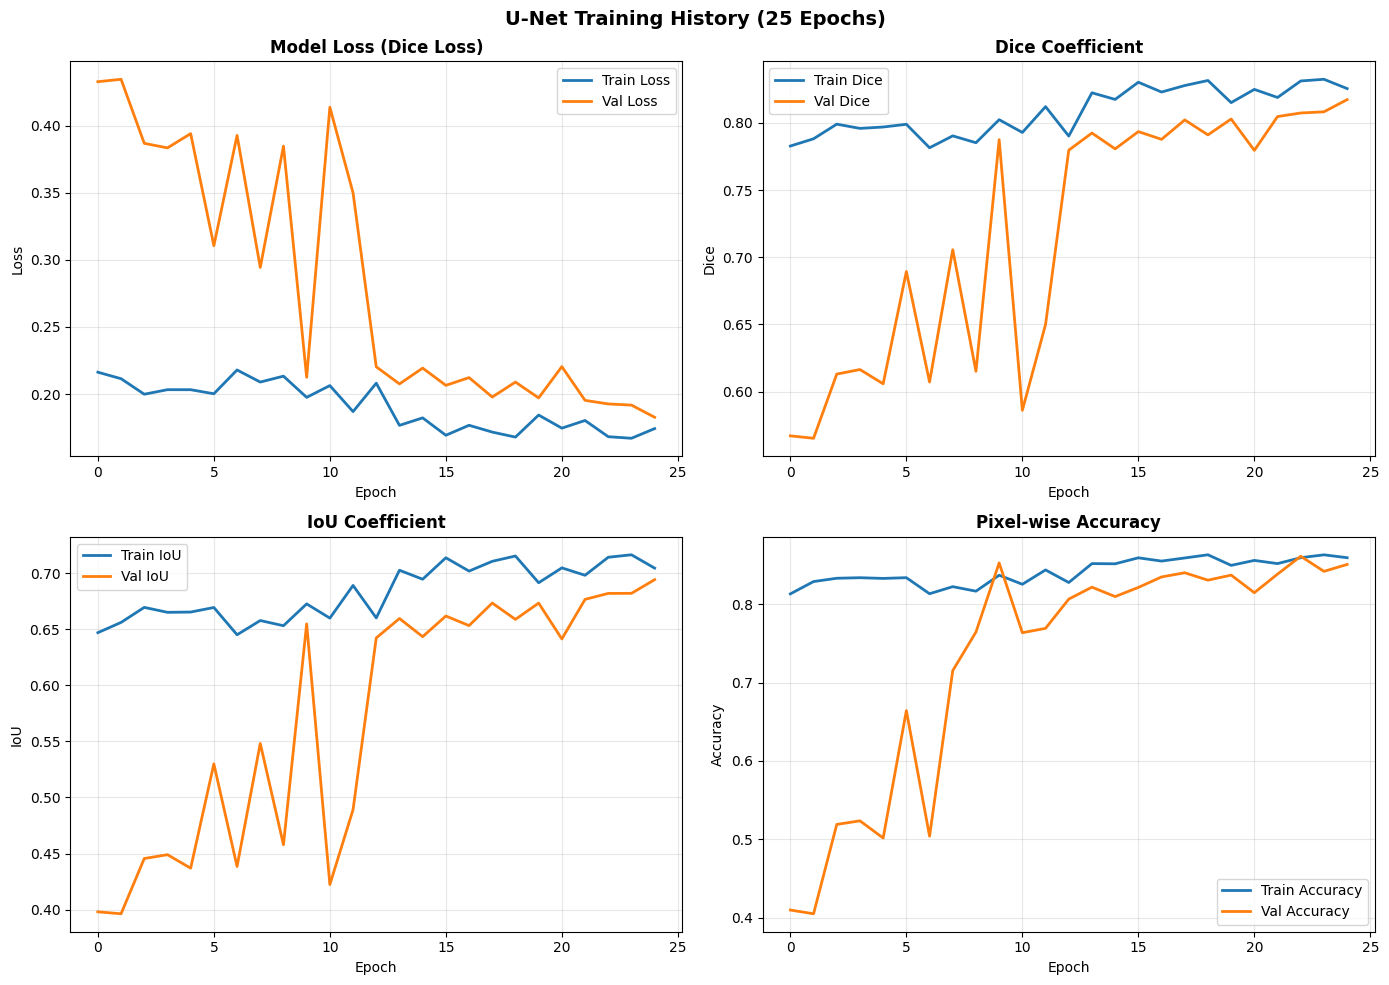

✅ Training history plotted!


In [23]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss (Dice Loss)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice Coefficient
axes[0, 1].plot(history.history['dice_coefficient'], label='Train Dice', linewidth=2)
axes[0, 1].plot(history.history['val_dice_coefficient'], label='Val Dice', linewidth=2)
axes[0, 1].set_title('Dice Coefficient', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Dice')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU Coefficient
axes[1, 0].plot(history.history['iou_coefficient'], label='Train IoU', linewidth=2)
axes[1, 0].plot(history.history['val_iou_coefficient'], label='Val IoU', linewidth=2)
axes[1, 0].set_title('IoU Coefficient', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('IoU')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy
axes[1, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1, 1].set_title('Pixel-wise Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('U-Net Training History (25 Epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Training history plotted!")

# Step 4: Evaluation

In [32]:
print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70 + "\n")

# Get predictions on test set
y_true_all = []
y_pred_all = []

print("Generating predictions on test set...")
for test_images_batch, test_masks_batch in test_pipeline:
    predictions = unet_model.predict(test_images_batch, verbose=0)

    # Convert to binary (threshold at 0.5)
    pred_binary = (predictions > 0.5).astype(np.int32)

    # Flatten for metrics
    y_pred_all.append(pred_binary.flatten())
    y_true_all.append(test_masks_batch.numpy().flatten())

# Concatenate all batches
y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print(f"Total pixels evaluated: {len(y_true_all):,}")


MODEL EVALUATION ON TEST SET

Generating predictions on test set...
Total pixels evaluated: 23,756,800


In [33]:
print("\n" + "="*70)
print("PER-CLASS IoU (INTERSECTION OVER UNION)")
print("="*70 + "\n")

iou_scores = {}
for class_id, class_name in enumerate(CLASS_NAMES):
    # True positives
    tp = np.sum((y_true_all == class_id) & (y_pred_all == class_id))
    # False positives
    fp = np.sum((y_true_all != class_id) & (y_pred_all == class_id))
    # False negatives
    fn = np.sum((y_true_all == class_id) & (y_pred_all != class_id))

    # IoU = TP / (TP + FP + FN)
    iou = tp / (tp + fp + fn + 1e-8)
    iou_scores[class_id] = iou

    print(f"{class_name:<15} IoU: {iou:.4f}")

# Mean IoU
miou = np.mean(list(iou_scores.values()))
print(f"\n{'mIoU (Mean IoU)':<15} {miou:.4f}")


PER-CLASS IoU (INTERSECTION OVER UNION)

Non-flood       IoU: 0.7543
Flood           IoU: 0.6847

mIoU (Mean IoU) 0.7195


In [34]:
print("\n" + "="*70)
print("PER-CLASS DICE COEFFICIENT")
print("="*70 + "\n")

dice_scores = {}
for class_id, class_name in enumerate(CLASS_NAMES):
    # True positives
    tp = np.sum((y_true_all == class_id) & (y_pred_all == class_id))
    # False positives
    fp = np.sum((y_true_all != class_id) & (y_pred_all == class_id))
    # False negatives
    fn = np.sum((y_true_all == class_id) & (y_pred_all != class_id))

    # Dice = 2*TP / (2*TP + FP + FN)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    dice_scores[class_id] = dice

    print(f"{class_name:<15} Dice: {dice:.4f}")

# Mean Dice
mean_dice = np.mean(list(dice_scores.values()))
print(f"\n{'Mean Dice':<15} {mean_dice:.4f}")


PER-CLASS DICE COEFFICIENT

Non-flood       Dice: 0.8600
Flood           Dice: 0.8128

Mean Dice       0.8364



PIXEL-LEVEL CONFUSION MATRIX

Confusion Matrix:
                Pred: 0         Pred: 1        
Non-flood            11,686,703       2,557,312
Flood                 1,248,487       8,264,298


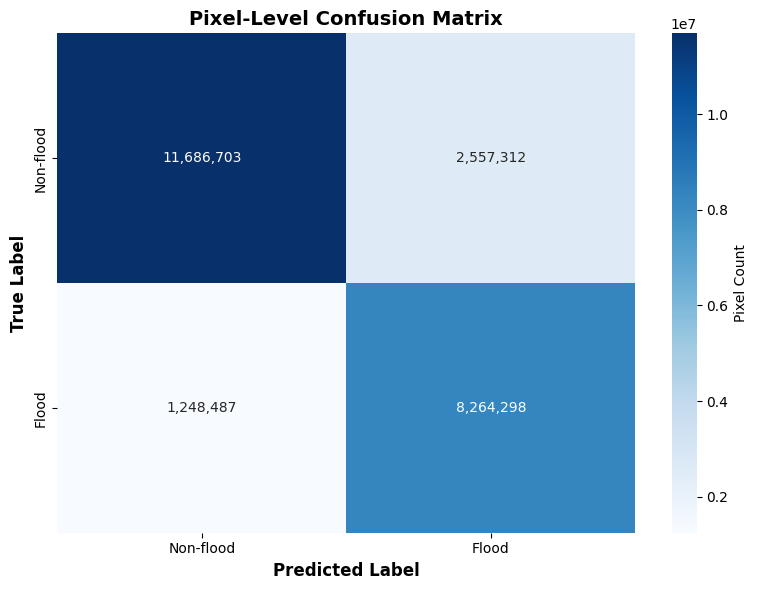

In [35]:
print("\n" + "="*70)
print("PIXEL-LEVEL CONFUSION MATRIX")
print("="*70 + "\n")

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])

print("Confusion Matrix:")
print(f"{'':>15} {'Pred: 0':<15} {'Pred: 1':<15}")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:<15} {cm[i, 0]:>15,} {cm[i, 1]:>15,}")

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

sensitivity = tp / (tp + fn + 1e-8)  # Recall for flood class
specificity = tn / (tn + fp + 1e-8)  # Recall for non-flood class
precision = tp / (tp + fp + 1e-8)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity + 1e-8)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt=',.0f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Pixel Count'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Pixel-Level Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [36]:
print("\n" + "="*70)
print("EVALUATION SUMMARY")
print("="*70 + "\n")

summary_data = {
    'Class': CLASS_NAMES,
    'IoU': [iou_scores[i] for i in range(NUM_CLASSES)],
    'Dice': [dice_scores[i] for i in range(NUM_CLASSES)]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n{'Overall Metrics':<20}")
print(f"  mIoU:        {miou:.4f}")
print(f"  Mean Dice:   {mean_dice:.4f}")
print(f"  Sensitivity: {sensitivity:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  F1-Score:    {f1_score:.4f}")
print("="*70)



EVALUATION SUMMARY

    Class      IoU     Dice
Non-flood 0.754346 0.859974
    Flood 0.684692 0.812839

Overall Metrics     
  mIoU:        0.7195
  Mean Dice:   0.8364
  Sensitivity: 0.8688
  Specificity: 0.8205
  F1-Score:    0.8128


## Visualizations on both good and poor predictions


VISUALIZING POOR PREDICTIONS



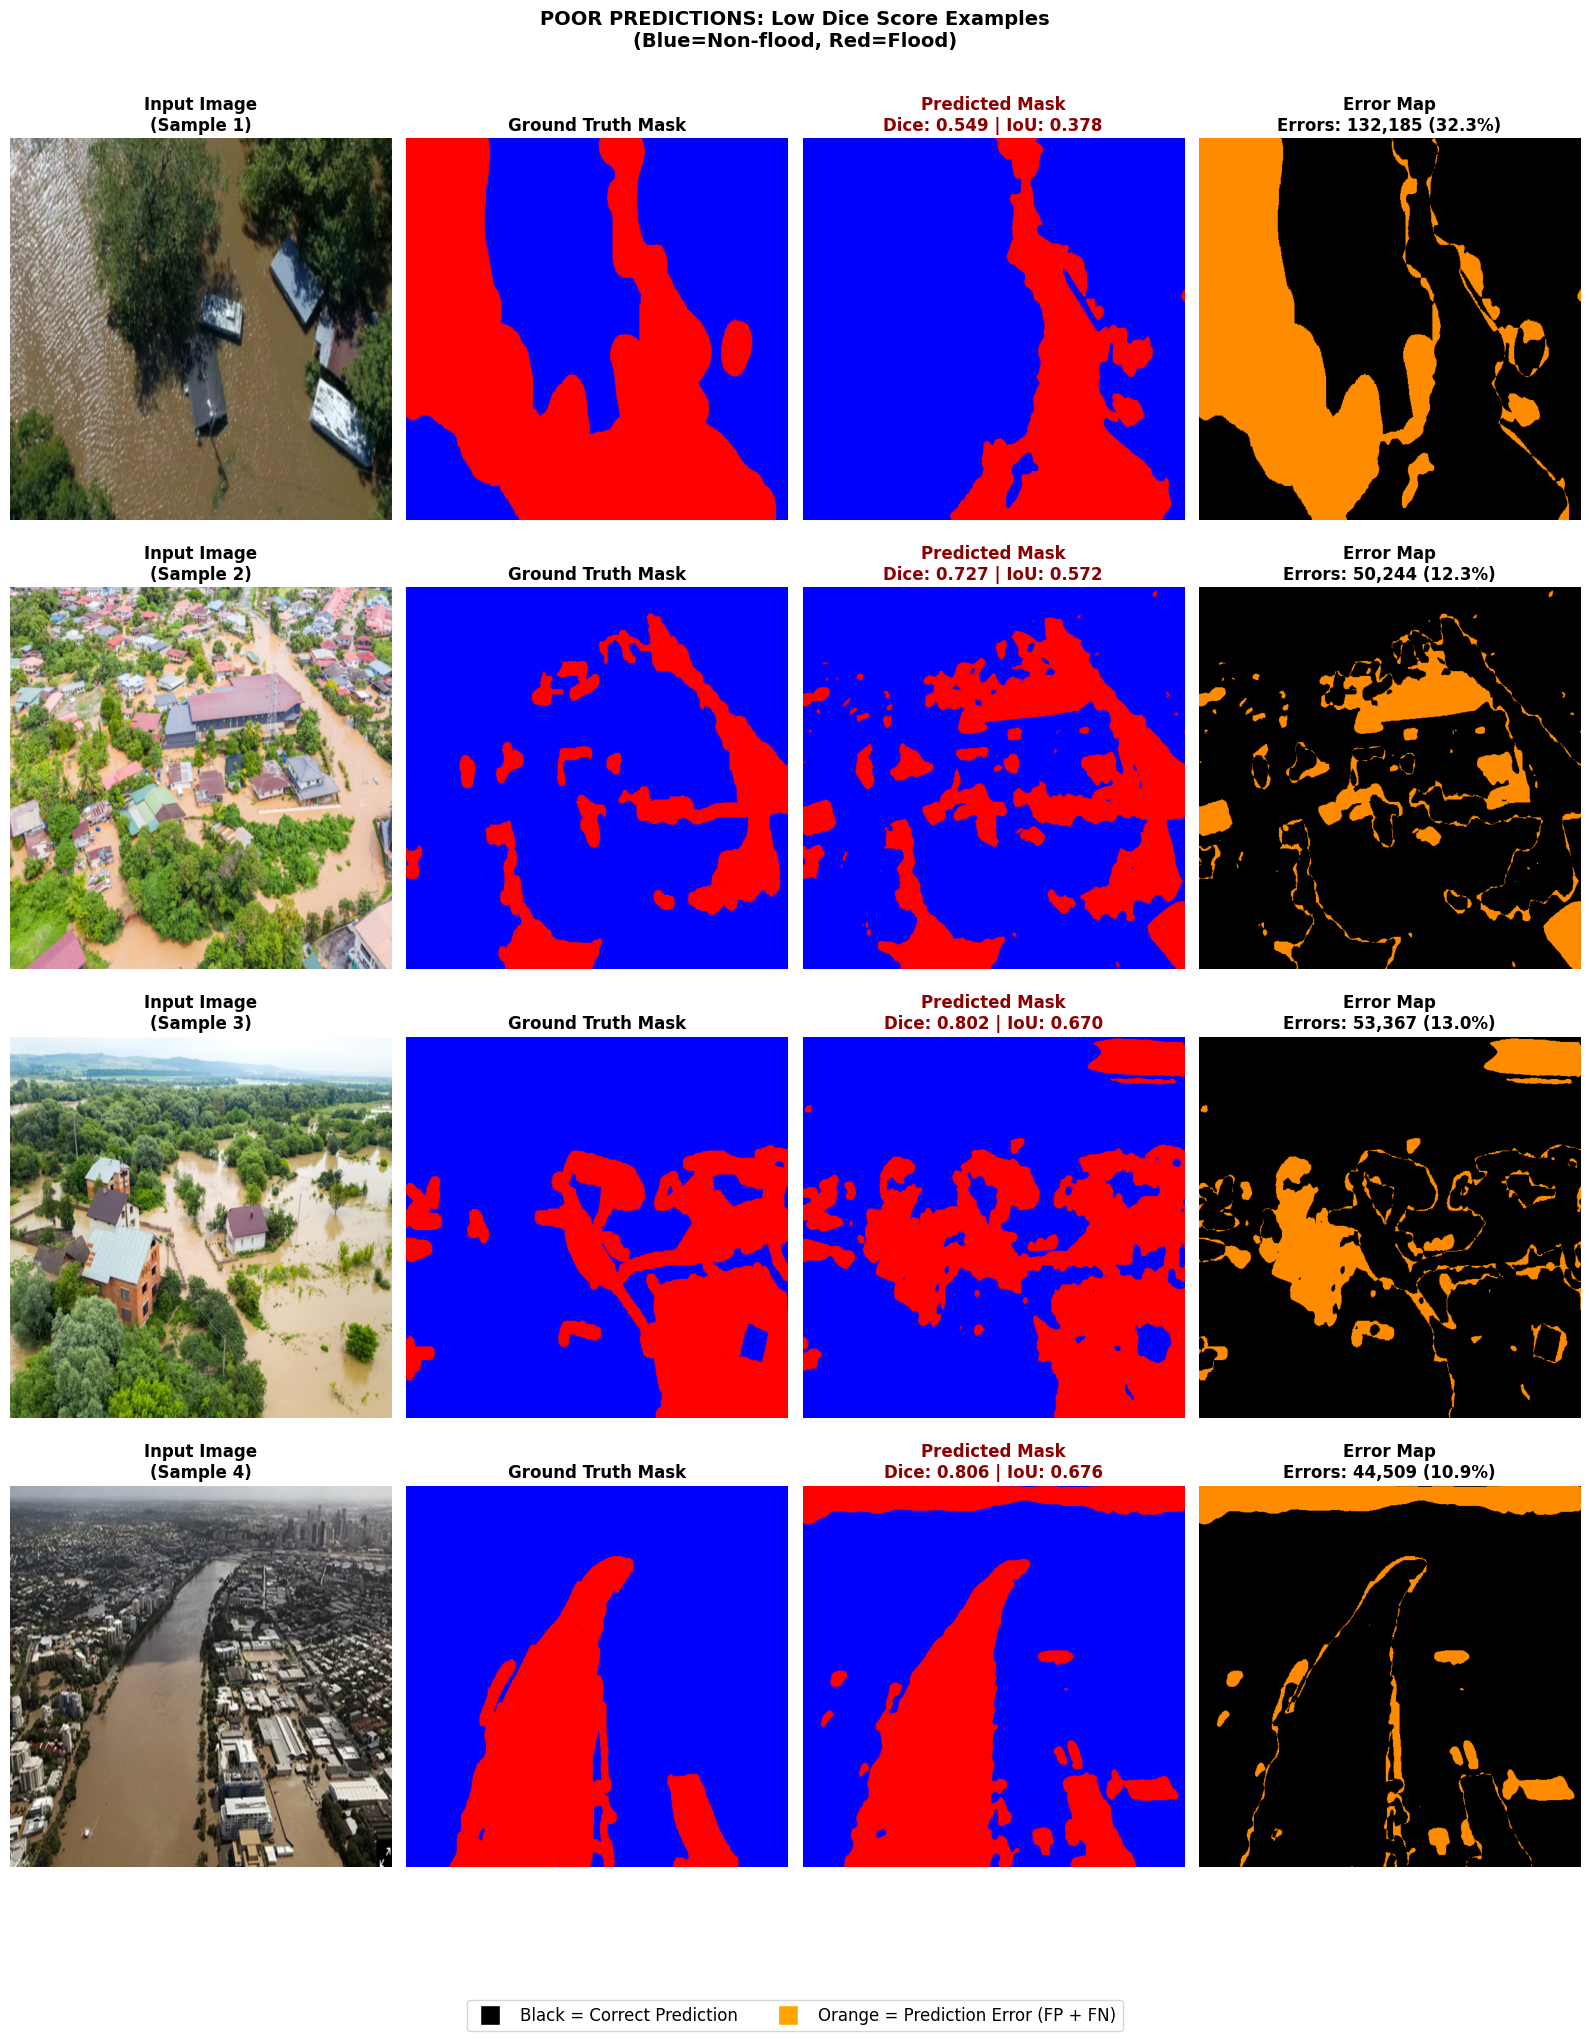


POOR PREDICTION ANALYSIS

Poor Sample 1:
  Dice Score:        0.5489
  IoU Score:         -1.0081
  True Positives:    36,597,058
  False Positives:   19,675,582
  False Negatives:   94,665,022
  True Negatives:    111,206,338

Poor Sample 2:
  Dice Score:        0.7273
  IoU Score:         -1.0137
  True Positives:    13,654,185
  False Positives:   59,738,455
  False Negatives:   30,892,375
  True Negatives:    157,858,985

Poor Sample 3:
  Dice Score:        0.8023
  IoU Score:         -1.0084
  True Positives:    32,513,848
  False Positives:   63,420,872
  False Negatives:   44,326,472
  True Negatives:    121,882,808

Poor Sample 4:
  Dice Score:        0.8065
  IoU Score:         -1.0137
  True Positives:    17,009,188
  False Positives:   66,377,052
  False Negatives:   46,794,972
  True Negatives:    131,962,788



In [41]:
def visualize_poor_predictions(dataset, num_samples=3, model=unet_model):
    """
    Visualize POOR predictions with error maps.
    """

    predictions_list = []
    images_list = []
    masks_list = []

    # Collect predictions
    for test_images_batch, test_masks_batch in dataset:
        preds = model.predict(test_images_batch, verbose=0)
        predictions_list.append(preds)
        images_list.append(test_images_batch.numpy())
        masks_list.append(test_masks_batch.numpy())

        if len(predictions_list) * len(test_images_batch) >= num_samples * 2:
            break

    # Concatenate
    all_predictions = np.concatenate(predictions_list, axis=0)
    all_images = np.concatenate(images_list, axis=0)
    all_masks = np.concatenate(masks_list, axis=0)

    # Calculate Dice scores
    dice_scores = []
    for i in range(len(all_predictions)):
        pred_binary = (all_predictions[i] > 0.5).astype(np.float32)
        gt = all_masks[i].squeeze()

        intersection = np.sum(pred_binary.squeeze() * gt)
        dice = (2 * intersection) / (np.sum(pred_binary.squeeze()) + np.sum(gt) + 1e-8)
        dice_scores.append(dice)

    dice_scores = np.array(dice_scores)

    # Select worst predictions
    worst_indices = np.argsort(dice_scores)[:num_samples]

    # Create visualization
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 5 * num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for plot_idx, sample_idx in enumerate(worst_indices):
        image = all_images[sample_idx]
        gt_mask = all_masks[sample_idx].squeeze()
        pred = all_predictions[sample_idx].squeeze()
        pred_binary = (pred > 0.5).astype(np.float32)
        dice = dice_scores[sample_idx]
        iou = np.sum(pred_binary * gt_mask) / (np.sum(pred_binary) + np.sum(gt_mask) - np.sum(pred_binary * gt_mask) + 1e-8)

        # ========== INPUT IMAGE ==========
        axes[plot_idx, 0].imshow(image)
        axes[plot_idx, 0].set_title(f'Input Image\n(Sample {plot_idx + 1})',
                                    fontsize=12, fontweight='bold')
        axes[plot_idx, 0].axis('off')

        # ========== GROUND TRUTH MASK ==========
        gt_colored = COLORMAP[gt_mask.astype(int)]
        axes[plot_idx, 1].imshow(gt_colored)
        axes[plot_idx, 1].set_title('Ground Truth Mask', fontsize=12, fontweight='bold')
        axes[plot_idx, 1].axis('off')

        # ========== PREDICTED MASK ==========
        pred_colored = COLORMAP[pred_binary.astype(int)]
        axes[plot_idx, 2].imshow(pred_colored)
        axes[plot_idx, 2].set_title(f'Predicted Mask\nDice: {dice:.3f} | IoU: {iou:.3f}',
                                    fontsize=12, fontweight='bold', color='darkred')
        axes[plot_idx, 2].axis('off')

        # ========== ERROR MAP ==========
        # Single color for all errors (orange/red)
        # Black = Correct predictions
        # Orange/Red = Errors (both FP and FN)

        error_map = np.zeros((gt_mask.shape[0], gt_mask.shape[1], 3), dtype=np.uint8)

        # Correct predictions (black background)
        error_map[:, :] = [0, 0, 0]  # Black = correct

        # False Positives (predicted flood, but actually non-flood)
        fp = (pred_binary == 1) & (gt_mask == 0)
        error_map[fp] = [255, 140, 0]  # Orange = false positive

        # False Negatives (predicted non-flood, but actually flood)
        fn = (pred_binary == 0) & (gt_mask == 1)
        error_map[fn] = [255, 140, 0]  # Orange = false negative

        # Count errors
        total_errors = np.sum(fp) + np.sum(fn)
        error_pct = 100 * total_errors / (gt_mask.shape[0] * gt_mask.shape[1])

        axes[plot_idx, 3].imshow(error_map)
        axes[plot_idx, 3].set_title(f'Error Map\nErrors: {total_errors:,} ({error_pct:.1f}%)',
                                    fontsize=12, fontweight='bold')
        axes[plot_idx, 3].axis('off')

    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', label='Black = Correct Prediction',
                  markerfacecolor='black', markersize=15),
        plt.Line2D([0], [0], marker='s', color='w', label='Orange = Prediction Error (FP + FN)',
                  markerfacecolor='orange', markersize=15)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
              fontsize=12, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('POOR PREDICTIONS: Low Dice Score Examples\n(Blue=Non-flood, Red=Flood)',
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0.04, 1, 0.99])
    plt.show()

    # Print statistics
    print(f"\n" + "="*70)
    print(f"POOR PREDICTION ANALYSIS")
    print(f"="*70 + "\n")

    for idx, sample_idx in enumerate(worst_indices):
        pred_binary = (all_predictions[sample_idx] > 0.5).astype(np.float32)
        gt_mask = all_masks[sample_idx].squeeze()
        dice = dice_scores[sample_idx]
        iou = np.sum(pred_binary * gt_mask) / (np.sum(pred_binary) + np.sum(gt_mask) - np.sum(pred_binary * gt_mask) + 1e-8)

        tp = np.sum((pred_binary == 1) & (gt_mask == 1))
        fp = np.sum((pred_binary == 1) & (gt_mask == 0))
        fn = np.sum((pred_binary == 0) & (gt_mask == 1))
        tn = np.sum((pred_binary == 0) & (gt_mask == 0))

        print(f"Poor Sample {idx + 1}:")
        print(f"  Dice Score:        {dice:.4f}")
        print(f"  IoU Score:         {iou:.4f}")
        print(f"  True Positives:    {tp:,}")
        print(f"  False Positives:   {fp:,}")
        print(f"  False Negatives:   {fn:,}")
        print(f"  True Negatives:    {tn:,}")
        print()

print("\n" + "="*70)
print("VISUALIZING POOR PREDICTIONS")
print("="*70 + "\n")

visualize_poor_predictions(test_pipeline, num_samples=4, model=unet_model)


VISUALIZING GOOD PREDICTIONS



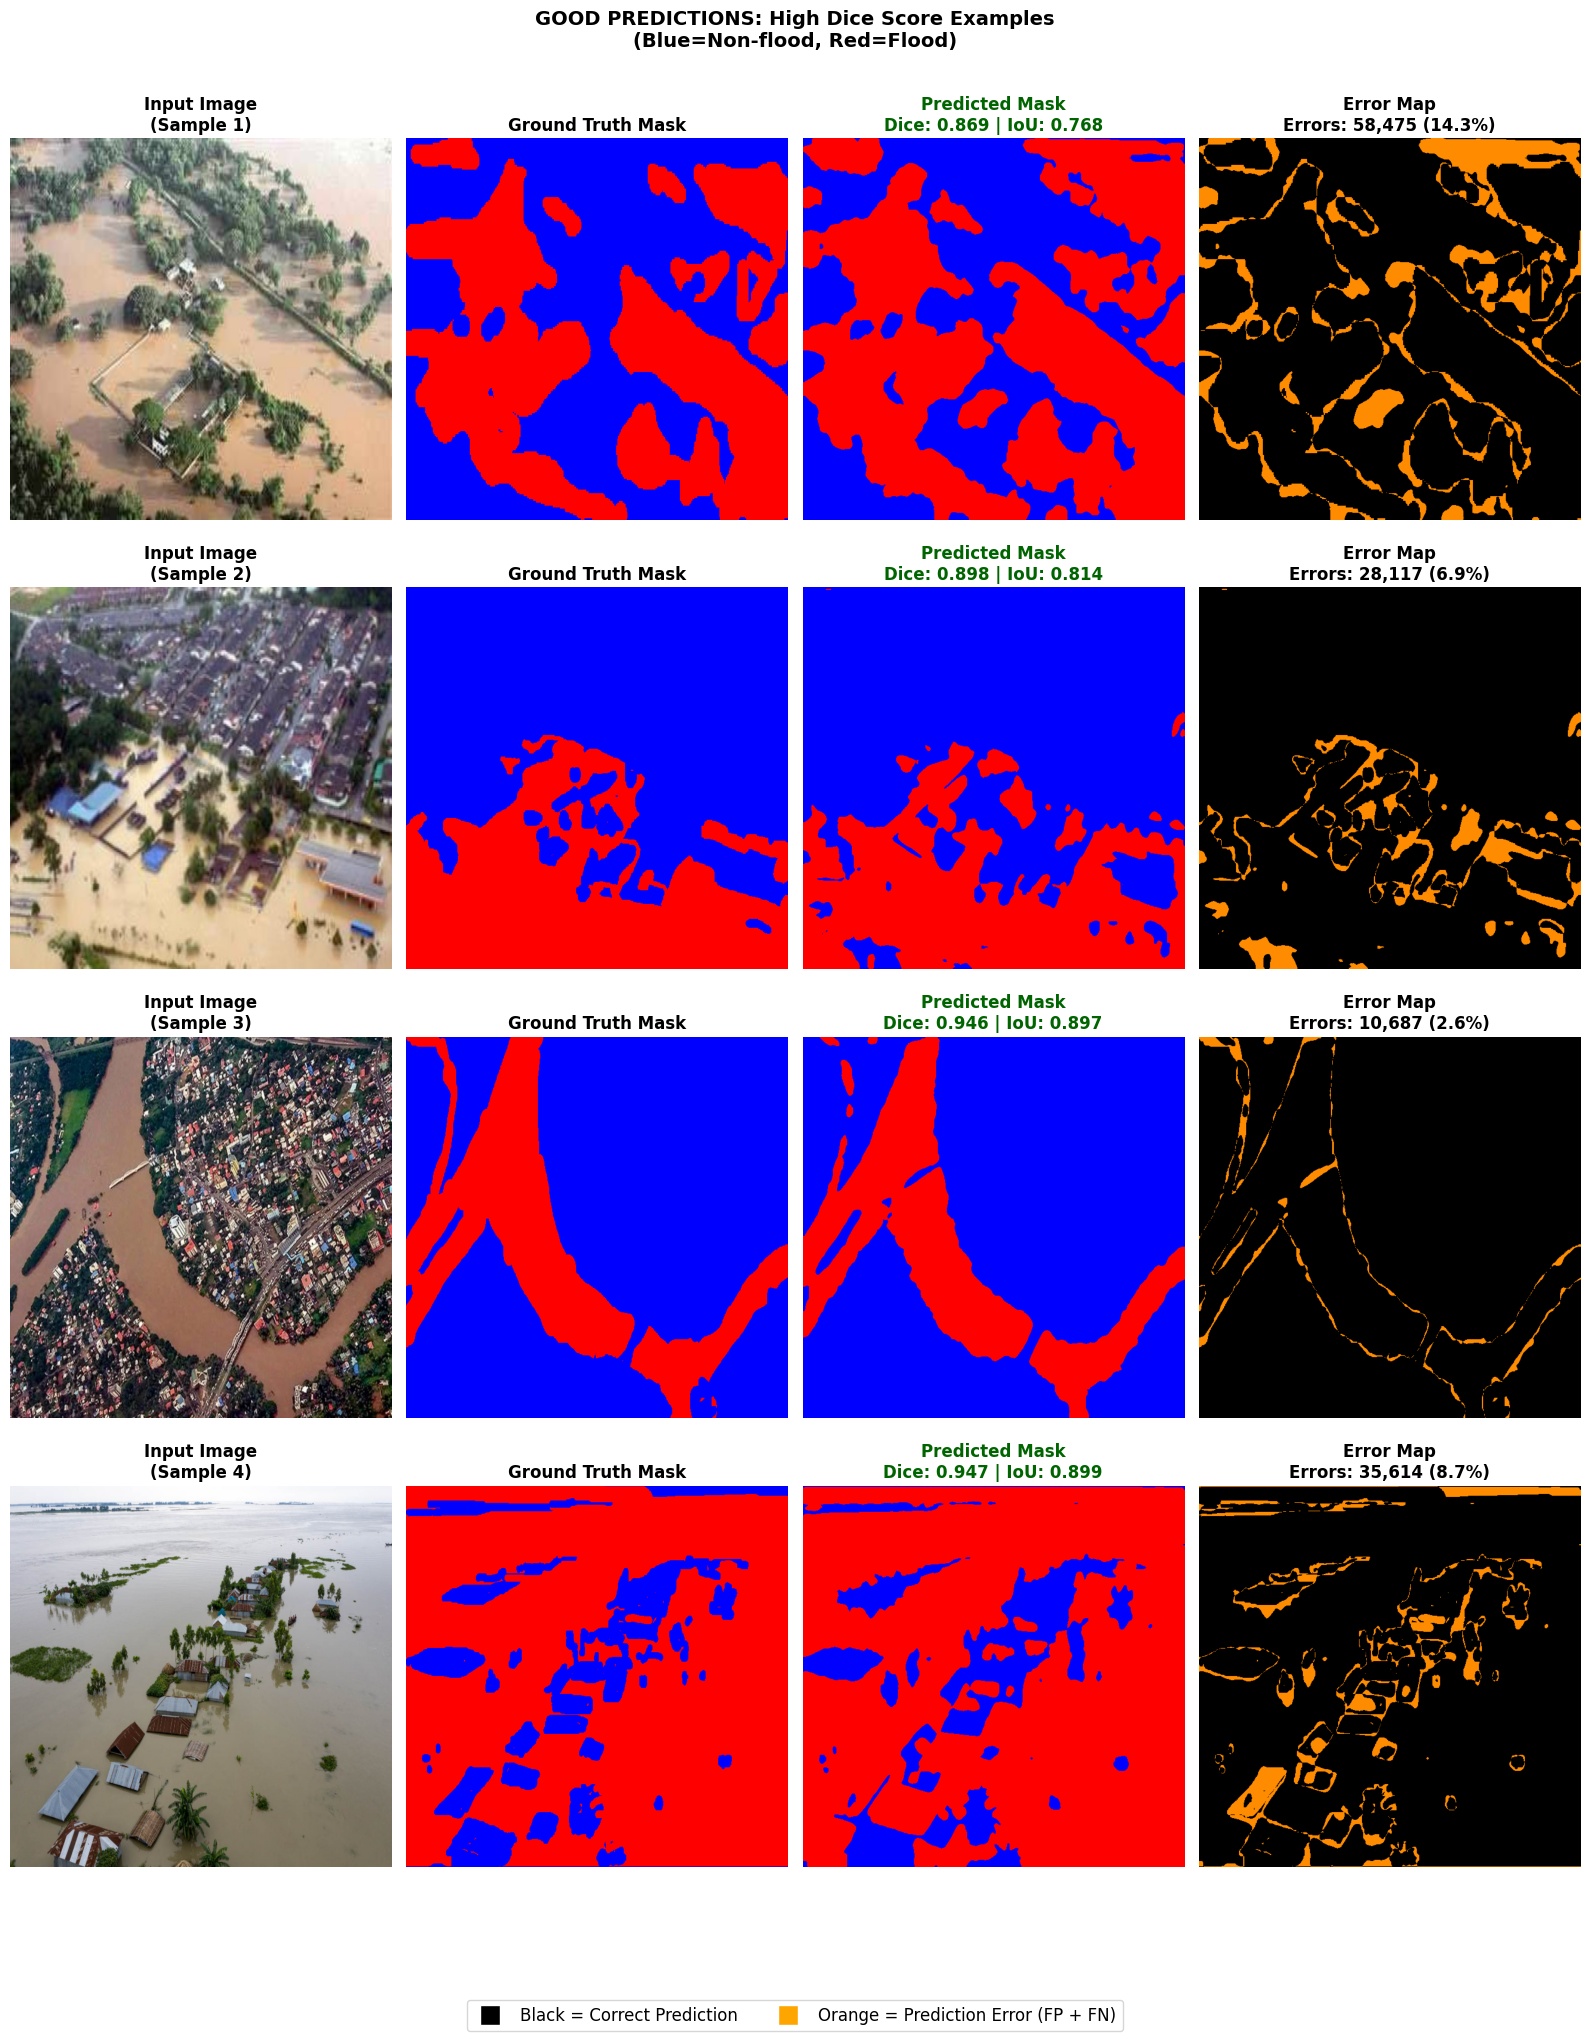


GOOD PREDICTION ANALYSIS

Good Sample 1:
  Dice Score:        0.8689
  IoU Score:         -1.0059
  True Positives:    76,490,815
  False Positives:   79,615,425
  False Negatives:   52,858,945
  True Negatives:    52,858,945

Good Sample 2:
  Dice Score:        0.8976
  IoU Score:         -1.0113
  True Positives:    24,674,469
  False Positives:   60,968,411
  False Negatives:   65,438,811
  True Negatives:    65,438,811

Good Sample 3:
  Dice Score:        0.9458
  IoU Score:         -1.0140
  True Positives:    14,325,464
  False Positives:   47,327,656
  False Negatives:   50,331,176
  True Negatives:    50,331,176

Good Sample 4:
  Dice Score:        0.9470
  IoU Score:         -1.0038
  True Positives:    176,058,328
  False Positives:   39,882,792
  False Negatives:   37,724,712
  True Negatives:    37,724,712



In [42]:
# ============================================================
# VISUALIZATION: Good Predictions (Separate Plot)
# ============================================================

def visualize_good_predictions(dataset, num_samples=3, model=unet_model):
    """
    Visualize GOOD predictions with error maps.
    """

    predictions_list = []
    images_list = []
    masks_list = []

    # Collect predictions
    for test_images_batch, test_masks_batch in dataset:
        preds = model.predict(test_images_batch, verbose=0)
        predictions_list.append(preds)
        images_list.append(test_images_batch.numpy())
        masks_list.append(test_masks_batch.numpy())

        if len(predictions_list) * len(test_images_batch) >= num_samples * 2:
            break

    # Concatenate
    all_predictions = np.concatenate(predictions_list, axis=0)
    all_images = np.concatenate(images_list, axis=0)
    all_masks = np.concatenate(masks_list, axis=0)

    # Calculate Dice scores
    dice_scores = []
    for i in range(len(all_predictions)):
        pred_binary = (all_predictions[i] > 0.5).astype(np.float32)
        gt = all_masks[i].squeeze()

        intersection = np.sum(pred_binary.squeeze() * gt)
        dice = (2 * intersection) / (np.sum(pred_binary.squeeze()) + np.sum(gt) + 1e-8)
        dice_scores.append(dice)

    dice_scores = np.array(dice_scores)

    # Select best predictions
    best_indices = np.argsort(dice_scores)[-num_samples:]

    # Create visualization
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 5 * num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for plot_idx, sample_idx in enumerate(best_indices):
        image = all_images[sample_idx]
        gt_mask = all_masks[sample_idx].squeeze()
        pred = all_predictions[sample_idx].squeeze()
        pred_binary = (pred > 0.5).astype(np.float32)
        dice = dice_scores[sample_idx]
        iou = np.sum(pred_binary * gt_mask) / (np.sum(pred_binary) + np.sum(gt_mask) - np.sum(pred_binary * gt_mask) + 1e-8)

        # ========== INPUT IMAGE ==========
        axes[plot_idx, 0].imshow(image)
        axes[plot_idx, 0].set_title(f'Input Image\n(Sample {plot_idx + 1})',
                                    fontsize=12, fontweight='bold')
        axes[plot_idx, 0].axis('off')

        # ========== GROUND TRUTH MASK ==========
        gt_colored = COLORMAP[gt_mask.astype(int)]
        axes[plot_idx, 1].imshow(gt_colored)
        axes[plot_idx, 1].set_title('Ground Truth Mask', fontsize=12, fontweight='bold')
        axes[plot_idx, 1].axis('off')

        # ========== PREDICTED MASK ==========
        pred_colored = COLORMAP[pred_binary.astype(int)]
        axes[plot_idx, 2].imshow(pred_colored)
        axes[plot_idx, 2].set_title(f'Predicted Mask\nDice: {dice:.3f} | IoU: {iou:.3f}',
                                    fontsize=12, fontweight='bold', color='darkgreen')
        axes[plot_idx, 2].axis('off')

        # ========== ERROR MAP ==========
        # Black = Correct predictions
        # Orange/Red = Errors (both FP and FN)

        error_map = np.zeros((gt_mask.shape[0], gt_mask.shape[1], 3), dtype=np.uint8)

        # Correct predictions (black background)
        error_map[:, :] = [0, 0, 0]  # Black = correct

        # False Positives
        fp = (pred_binary == 1) & (gt_mask == 0)
        error_map[fp] = [255, 140, 0]  # Orange = false positive

        # False Negatives
        fn = (pred_binary == 0) & (gt_mask == 1)
        error_map[fn] = [255, 140, 0]  # Orange = false negative

        # Count errors
        total_errors = np.sum(fp) + np.sum(fn)
        error_pct = 100 * total_errors / (gt_mask.shape[0] * gt_mask.shape[1])

        axes[plot_idx, 3].imshow(error_map)
        axes[plot_idx, 3].set_title(f'Error Map\nErrors: {total_errors:,} ({error_pct:.1f}%)',
                                    fontsize=12, fontweight='bold')
        axes[plot_idx, 3].axis('off')

    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', label='Black = Correct Prediction',
                  markerfacecolor='black', markersize=15),
        plt.Line2D([0], [0], marker='s', color='w', label='Orange = Prediction Error (FP + FN)',
                  markerfacecolor='orange', markersize=15)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
              fontsize=12, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('GOOD PREDICTIONS: High Dice Score Examples\n(Blue=Non-flood, Red=Flood)',
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0.04, 1, 0.99])
    plt.show()

    # Print statistics
    print(f"\n" + "="*70)
    print(f"GOOD PREDICTION ANALYSIS")
    print(f"="*70 + "\n")

    for idx, sample_idx in enumerate(best_indices):
        pred_binary = (all_predictions[sample_idx] > 0.5).astype(np.float32)
        gt_mask = all_masks[sample_idx].squeeze()
        dice = dice_scores[sample_idx]
        iou = np.sum(pred_binary * gt_mask) / (np.sum(pred_binary) + np.sum(gt_mask) - np.sum(pred_binary * gt_mask) + 1e-8)

        tp = np.sum((pred_binary == 1) & (gt_mask == 1))
        fp = np.sum((pred_binary == 1) & (gt_mask == 0))
        fn = np.sum((pred_binary == 0) & (gt_mask == 1))
        tn = np.sum((pred_binary == 0) & (gt_mask == 1))

        print(f"Good Sample {idx + 1}:")
        print(f"  Dice Score:        {dice:.4f}")
        print(f"  IoU Score:         {iou:.4f}")
        print(f"  True Positives:    {tp:,}")
        print(f"  False Positives:   {fp:,}")
        print(f"  False Negatives:   {fn:,}")
        print(f"  True Negatives:    {tn:,}")
        print()

print("\n" + "="*70)
print("VISUALIZING GOOD PREDICTIONS")
print("="*70 + "\n")

visualize_good_predictions(test_pipeline, num_samples=4, model=unet_model)